Loading GridInfo.h5...
(29161, 1) (241, 121) (241, 121)
Grid Dimensions: (241, 121) | Total points: 29161


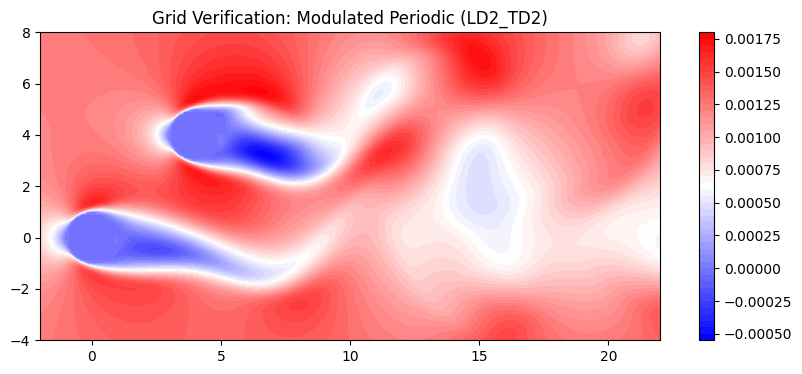

Available keys in snapshots_ux_mapped.h5: ['snaps']


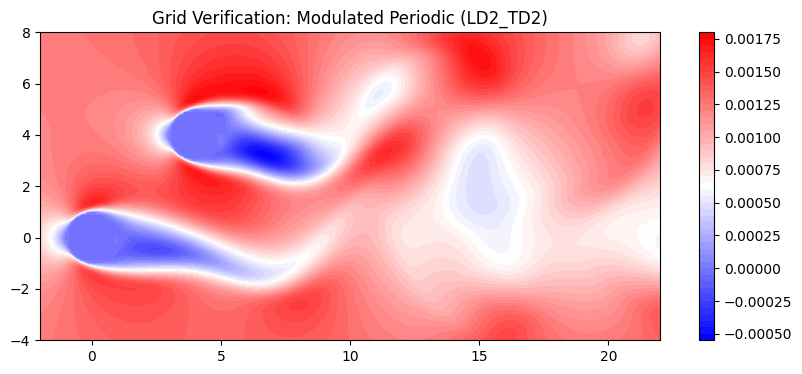

Alignment verified: 29161 spatial points.

--- Data Split Summary ---
Total Snapshots: 6600
Training set:    5940 snapshots (0 to 5939)
Testing set:     660 snapshots (5940 to 6599)
Saving to /media/chris-remote/Projects/ONeill/estimation/output/kevin_2cylinder/MP/MP_velocity_unified.h5...
Success! Unified H5 saved: /media/chris-remote/Projects/ONeill/estimation/output/kevin_2cylinder/MP/MP_velocity_unified.h5


In [29]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Configuration & Paths ---
base_dir = "/media/chris-remote/Projects/ONeill/estimation"
# Input is now the directory where your converted .h5 files live
input_dir = os.path.join(base_dir, "data/kevin_2cylinder/LD2_TD2") 
output_dir = os.path.join(base_dir, "output/kevin_2cylinder/MP")
os.makedirs(output_dir, exist_ok=True)


# --- 2. Load Grid ---
print("Loading GridInfo.h5...")
grid_path = os.path.join(input_dir, "GridInfo.h5")
with h5py.File(grid_path, 'r') as f:
    Xi = np.array(f['XI'],order='F').transpose()  # Ensure we read in C order to match Python's row-major format
    Yi = np.array(f['YI'],order='F').transpose()
    SampleField = np.array(f['SampleField'],order='F')

Xi = np.ascontiguousarray(Xi)  # Ensure C-contiguous for Python processing
Yi = np.ascontiguousarray(Yi)
SampleField = np.ascontiguousarray(SampleField)  # Ensure C-contiguous for

#SampleField = SampleField[::-1]  # Flatten to match point-cloud format

print(SampleField.shape, Xi.shape, Yi.shape)  # Should all match in shape

# Flattening for point-cloud format (Row-major 'C' order to match Python standards)
x_flat = Xi.ravel()
y_flat = Yi.ravel()
grid_shape = Xi.shape

print(f"Grid Dimensions: {grid_shape} | Total points: {x_flat.size}")

# Verification Plot
plt.figure(figsize=(10, 4))
plt.contourf(Xi, Yi, SampleField.reshape(grid_shape), levels=50, cmap='bwr')
plt.title("Grid Verification: Modulated Periodic (LD2_TD2)")
plt.colorbar()
plt.show()

# --- 3. Load Velocity Snapshots (Already converted to .h5) ---
fn_ux = os.path.join(input_dir, "snapshots_ux_mapped.mat")
fn_uy = os.path.join(input_dir, "snapshots_uy_mapped.mat")
with h5py.File(fn_ux, 'r') as f_ux:
    print("Available keys in snapshots_ux_mapped.h5:", list(f_ux.keys()))
    ux = np.array(f_ux['snaps'])
with h5py.File(fn_uy, 'r') as f_uy:
    uy = np.array(f_uy['snaps'])

# Verification Plot
plt.figure(figsize=(10, 4))
plt.contourf(Xi, Yi, ux[0,:].reshape(grid_shape), levels=50, cmap='bwr')
plt.title("Grid Verification: Modulated Periodic (LD2_TD2)")
plt.colorbar()
plt.show()


# Filter out missing runs
runs_ux = ux
runs_uy = uy

# --- 4. Dimension Guard ---
# Ensure the columns match the flattened grid
if ux.shape[1] != x_flat.size:
    print(f"!!! ERROR: Data columns ({ux.shape[1]}) != Grid points ({x_flat.size})")
    print("Verify if the conversion script applied an extra transpose.")
else:
    print(f"Alignment verified: {ux.shape[1]} spatial points.")

# --- 5. Data Split Logic (Last 10% as Test Set) ---
n_total = ux.shape[0]
n_train = int(0.9 * n_total) # 90% for training
n_test = n_total - n_train   # 10% for testing

print(f"\n--- Data Split Summary ---")
print(f"Total Snapshots: {n_total}")
print(f"Training set:    {n_train} snapshots (0 to {n_train-1})")
print(f"Testing set:     {n_test} snapshots ({n_train} to {n_total-1})")

# Simple slicing for single-file dataset
ux_train = ux[:n_train, :]
uy_train = uy[:n_train, :]

ux_test = ux[n_train:, :]
uy_test = uy[n_train:, :]

# --- 6. Save Unified Dataset ---
h5_path = os.path.join(output_dir, "MP_velocity_unified.h5")
print(f"Saving to {h5_path}...")

with h5py.File(h5_path, 'w') as f:
    # Spatial Metadata
    f.create_dataset('x', data=x_flat)
    f.create_dataset('y', data=y_flat)
    f.create_dataset('grid_shape', data=np.array(grid_shape))
    f.create_dataset('XI', data=Xi)
    f.create_dataset('YI', data=Yi)
    
    # Training Group
    tr = f.create_group('train')
    tr.create_dataset('ux', data=ux_train.astype(np.float32))
    tr.create_dataset('uy', data=uy_train.astype(np.float32),)
    
    # Testing Group
    ts = f.create_group('test')
    ts.create_dataset('ux', data=ux_test.astype(np.float32))
    ts.create_dataset('uy', data=uy_test.astype(np.float32))

print(f"Success! Unified H5 saved: {h5_path}")

In [7]:
import os
import h5py
import numpy as np
from scipy.io import loadmat

def convert_mat_to_h5(mat_path, h5_path):
    """
    Scans a MATLAB file for all data keys and clones them into an HDF5 file.
    Handles both legacy (v7) and HDF5-based (-v7.3) MATLAB formats.
    """
    print(f"Converting: {os.path.basename(mat_path)} -> {os.path.basename(h5_path)}")
    
    try:
        # --- Attempt Legacy Loading (v7 and earlier) ---
        data_dict = loadmat(mat_path)
        # Filter out MATLAB metadata keys
        valid_keys = [k for k in data_dict.keys() if not k.startswith('__')]
        
        with h5py.File(h5_path, 'w') as h5f:
            for key in valid_keys:
                data = data_dict[key]
                # Scipy sometimes loads scalars as 0-d arrays; we ensure they are arrays
                h5f.create_dataset(key, data=data)
                print(f"  [v7] Saved key: '{key}' | Shape: {data.shape}")
        print("--> Conversion successful using scipy.io.loadmat")

    except NotImplementedError:
        # --- Fallback for v7.3 (HDF5-based) ---
        with h5py.File(mat_path, 'r') as mat_f:
            # Skip HDF5 specific metadata groups
            valid_keys = [k for k in mat_f.keys() if k not in ['#refs#', '#subsystem#']]
            
            with h5py.File(h5_path, 'w') as h5f:
                for key in valid_keys:
                    # Note: h5py reads are transposed relative to MATLAB/Scipy
                    # We transpose back (.T) to maintain standard MATLAB indexing
                    data = mat_f[key][:].T
                    h5f.create_dataset(key, data=data)
                    print(f"  [v7.3] Saved key: '{key}' | Shape: {data.shape}")
        print("--> Conversion successful using h5py")

# --- EXECUTION ---
input_mat = os.path.join(input_dir, "GridInfo.mat")
output_h5 = os.path.join(input_dir, "GridInfo.h5")

convert_mat_to_h5(input_mat, output_h5)

Converting: GridInfo.mat -> GridInfo.h5
  [v7] Saved key: 'N_p' | Shape: (1, 1)
  [v7] Saved key: 'N_snap' | Shape: (1, 1)
  [v7] Saved key: 'SampleField' | Shape: (29161, 1)
  [v7] Saved key: 'U_inf' | Shape: (1, 1)
  [v7] Saved key: 'XI' | Shape: (121, 241)
  [v7] Saved key: 'YI' | Shape: (121, 241)
  [v7] Saved key: 'dia' | Shape: (1, 1)
  [v7] Saved key: 'f_capture' | Shape: (1, 1)
  [v7] Saved key: 'x' | Shape: (654919, 1)
  [v7] Saved key: 'xi' | Shape: (1, 241)
  [v7] Saved key: 'xi_grid' | Shape: (29161, 1)
  [v7] Saved key: 'y' | Shape: (654919, 1)
  [v7] Saved key: 'yi' | Shape: (1, 121)
  [v7] Saved key: 'yi_grid' | Shape: (29161, 1)
--> Conversion successful using scipy.io.loadmat
